# Waterfall

## Pré-requis (pour exécuter les tests)

- Le simulateur utilisé est `waterfall_simpy.py`.
- Il dépend de `simpy` (à installer dans le même environnement Python que votre kernel Jupyter).

Installation (si nécessaire) :
```bash
pip install simpy
```

In [27]:
from __future__ import annotations

from pathlib import Path
import csv
import sys
import statistics
import subprocess
from typing import Any


# Ajustez ces paramètres si les runs sont trop longs.
DEFAULT_SIM_TIME = 5_000
DEFAULT_RUNS = 20
DEFAULT_SEED = 42


if not Path("waterfall_simpy.py").exists():
    raise FileNotFoundError("waterfall_simpy.py introuvable dans le dossier courant.")

try:
    import simpy  # noqa: F401
except ModuleNotFoundError:
    print("Installation de 'simpy' via pip…")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "simpy"])
    import simpy  # noqa: F401


def run_waterfall(
    *,
    out_prefix: str,
    out_dir: str,
    lam: float,
    mu_exec: float,
    mu_send: float,
    K: int,
    ks: int = 0,
    kf: int = 0,
    sim_time: float = DEFAULT_SIM_TIME,
    grace: float = 200,
    runs: int = DEFAULT_RUNS,
    seed: int = DEFAULT_SEED,
    backup: str = "none",
    backup_p: float = 0.5,
) -> tuple[Path, Path]:
    """Lance `waterfall_simpy.py` et renvoie les chemins vers les CSV (summary, jobs)."""
    cmd = [
        "python3",
        "waterfall_simpy.py",
        "--lam",
        str(lam),
        "--mu-exec",
        str(mu_exec),
        "--mu-send",
        str(mu_send),
        "--K",
        str(K),
        "--ks",
        str(ks),
        "--kf",
        str(kf),
        "--sim-time",
        str(sim_time),
        "--grace",
        str(grace),
        "--runs",
        str(runs),
        "--seed",
        str(seed),
        "--backup",
        str(backup),
        "--backup-p",
        str(backup_p),
        "--out-dir",
        out_dir,
        "--out-prefix",
        out_prefix,
    ]
    subprocess.run(cmd, check=True)
    return (
        Path(out_dir) / f"{out_prefix}_summary.csv",
        Path(out_dir) / f"{out_prefix}_jobs.csv",
    )


def read_csv_dicts(path: Path) -> list[dict[str, str]]:
    with path.open(newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def mean_metric(rows: list[dict[str, str]], key: str) -> float:
    values = [float(r[key]) for r in rows if r.get(key) not in (None, "")]
    return statistics.mean(values) if values else 0.0


def summarize_experiment(summary_csv: Path) -> dict[str, float]:
    rows = read_csv_dicts(summary_csv)
    if not rows:
        return {}
    keys = [
        "rate_blocked_submit",
        "rate_blocked_forward",
        "rate_dropped",
        "mean_time_in_system",
        "var_time_in_system",
        "utilization_exec",
        "rest_in_backup",
        "rest_in_forward",
        "not_completed_yet",
        "arrivals",
        "completed",
    ]
    return {k: mean_metric(rows, k) for k in keys if k in rows[0]}


def print_table(rows: list[dict[str, Any]], cols: list[str]) -> None:
    def fmt(v: Any) -> str:
        if isinstance(v, float):
            return f"{v:.4g}"
        return str(v)

    widths: dict[str, int] = {}
    for c in cols:
        w = len(c)
        for r in rows:
            w = max(w, len(fmt(r.get(c, ""))))
        widths[c] = w

    header = " | ".join(c.ljust(widths[c]) for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in rows:
        print(" | ".join(fmt(r.get(c, "")).ljust(widths[c]) for c in cols))


## <span style="color:#4a90e2"> 1) Proposez un système d’attente modélisant le contexte décrit ci-dessus. Effectuez quelques simulations pour analyser son comportement selon les paramètres en jeu. 

Le workflow décrit se modélise par un **réseau de files en tandem** à deux étages :

- **Étape 1 (exécution de la test-suite)** : file FIFO servie par $K$ serveurs parallèles. Sous hypothèses standard (arrivées Poisson, services exponentiels), on l’approxime par une file $M/M/K$ de taux d’arrivée $\lambda$ et de taux de service par serveur $\mu_1$.
- **Étape 2 (envoi des résultats)** : file FIFO servie par un serveur unique, modélisable par $M/M/1$ de taux de service $\mu_2$.

On introduit les **charges** (taux d’occupation) :

$$
\rho_1 = \frac{\lambda}{K\mu_1},\qquad
\rho_2 = \frac{\lambda}{\mu_2}.
$$

Dans cette approximation, la stabilité requiert $\rho_1<1$ et $\rho_2<1$, c’est‑à‑dire $\lambda < K\mu_1$ et $\lambda < \mu_2$. Le goulet d’étranglement correspond à l’étage dont la charge est la plus proche de 1 (souvent l’envoi).

**Appui expérimental (tests ci-dessous)** en files infinies, avec $K=3$, $\mu_1=1$ (exécution) et $\mu_2=1.5$ (envoi) :
- Pour $\lambda=0.5$ et $\lambda=1$, le système reste stable : $\mathbb{E}[T]\approx 2.02$ puis $3.051$ et aucun backlog en fin de simulation.
- Dès $\lambda=2$, on a $\rho_2 = 2/1.5 \approx 1.33 > 1$ : le **temps de séjour moyen augmente très fortement** ($\approx 647$) et un backlog apparaît ($\approx 2200$ jobs non terminés).
- À $\lambda=3$ et $\lambda=4$, $\mathbb{E}[T]$ et le backlog augmentent encore (jusqu’à $\approx 1.6\times 10^3$), ce qui est cohérent avec une dynamique instable dominée par l’étape 2.

Ces observations confirment que, pour ces paramètres, l’**étape 2** est limitante : à $\lambda=2$, $\rho_1 = 2/(3\cdot 1)=2/3<1$ alors que $\rho_2>1$.

### Appui expérimental attendu

- Variation de λ, K, μ_exec, μ_send

- Observation du temps de séjour moyen et de sa divergence en régime instable

- Identification de l’étage limitant

In [28]:
# Tests Q1 — files infinies (ks=0, kf=0) : variation de λ, K, μ
# Interprétation attendue : quand le système approche/surpasse la saturation,
# - le temps moyen en système augmente fortement,
# - le backlog en fin de simulation (`not_completed_yet`) augmente.

OUT_DIR = "results_q1"

mu_exec = 1.0
mu_send = 1.5
K = 3
ks = 0  # infini
kf = 0  # infini

lam_values = [0.5, 1.0, 2.0, 3.0, 4.0]

rows = []
for lam in lam_values:
    prefix = f"q1_lam{lam}_K{K}_mue{mu_exec}_mus{mu_send}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup="none",
    )
    s = summarize_experiment(summary_csv)
    s.update({"lam": lam, "K": K, "mu_exec": mu_exec, "mu_send": mu_send})
    rows.append(s)

print_table(
    rows,
    cols=["lam", "mean_time_in_system", "utilization_exec", "not_completed_yet", "rest_in_forward"],
)


lam | mean_time_in_system | utilization_exec | not_completed_yet | rest_in_forward
----+---------------------+------------------+-------------------+----------------
0.5 | 2.02                | 0.1669           | 0                 | 0              
1   | 3.051               | 0.3344           | 0                 | 0              
2   | 647.4               | 0.6652           | 2200              | 2200           
3   | 1296                | 0.9973           | 7151              | 7151           
4   | 1629                | 1.04             | 1.22e+04          | 7815           


## <span style="color:#4a90e2"> 2) Avec une augmentation significative du nombre d’étudiants, l’hypothèse de files d’attente infinies devient irréaliste. On note ks et kf les tailles respectives des files d’exécution et de renvoi de résultats. Si un push tag est refusé, l’étudiant reçoit un message d’erreur. Si le résultat d’un moulinettage est refusé dans la seconde file, l’étudiant reçoit un retour vide.

### <span style="color:#4a90e2"> Discutez des proportions de refus selon les paramètres.

Avec des capacités finies, on distingue deux mécanismes de refus :

- **Refus à la soumission** : un tag est rejeté si le système d’exécution est plein. Dans notre simulateur, cela correspond à $N_{\mathrm{exec}}(t) \ge k_s$ (jobs en service + en attente), et la métrique associée est `rate_blocked_submit`.
- **Refus au renvoi** (retour vide / « page blanche ») : après exécution, si la file de renvoi contient déjà $k_f$ éléments en attente, le résultat ne peut pas entrer (sans back-up) et est perdu ; la métrique associée est `rate_dropped`.

Les proportions de refus dépendent de $\lambda$, de $k_s$ et $k_f$, mais aussi des capacités de service de chaque étage. L’expérience ci-dessous fixe $K=3$, $\mu_1=1$ (exécution), $\mu_2=1.5$ (envoi), $k_s=15$, $k_f=5$, sans back-up :

- Quand $\lambda$ augmente de 1 à 5, `rate_blocked_submit` croît fortement (de 0 à $\approx 0.399$), ce qui traduit la saturation progressive du premier étage sous contrainte de capacité.
- Le taux de « pages blanches » (`rate_dropped`) augmente d’abord ($\approx 0.031$ à $\lambda=1$, puis $\approx 0.437$ à $\lambda=3$) puis redescend ($\approx 0.302$ à $\lambda=5$). Cette **non‑monotonie** s’explique : quand $\lambda$ devient très élevé, davantage de tags sont bloqués en amont ($k_s$ plein), ce qui réduit le flux atteignant la file de renvoi et donc la probabilité de drop.
- Le temps de séjour moyen `mean_time_in_system` augmente globalement ($\approx 2.684$ à $\lambda=1$ jusqu’à $\approx 8.213$ à $\lambda=5$), indiquant une dégradation de l’expérience utilisateur pour les requêtes acceptées.

Enfin, en gardant $\lambda=4$ et $k_s,k_f$ constants, l’augmentation de $\mu_2$ fait chuter `rate_dropped` (de $\approx 0.548$ à $\mu_2=0.8$ vers $\approx 0.264$ à $\mu_2=2$) et diminue `mean_time_in_system` (de $\approx 11.47$ à $\approx 6.648$), alors que `rate_blocked_submit` reste $\approx 0.252$. Cela confirme que, dans ce réglage, l’envoi est le levier principal pour réduire les retours vides.

### Appui expérimental attendu

- Taux de refus submit (ks) vs λ

- Taux de “pages blanches” (kf) vs λ

- Influence de μ_send comparée à celle de ks/kf

In [29]:
# Tests Q2 — files finies : proportions de refus selon (λ, ks, kf, μ_send)
# Mesures principales :
# - rate_blocked_submit : refus à la soumission (ks plein)
# - rate_dropped        : "page blanche" (kf plein et pas de back-up)

OUT_DIR = "results_q2"

mu_exec = 1.0
K = 3
backup = "none"

# (1) Variation de λ pour des capacités données
ks = 15
kf = 5
mu_send = 1.5
lam_values = [1.0, 2.0, 3.0, 4.0, 5.0]

rows_lam = []
for lam in lam_values:
    prefix = f"q2_lam{lam}_ks{ks}_kf{kf}_mus{mu_send}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup=backup,
    )
    s = summarize_experiment(summary_csv)
    s.update({"lam": lam, "ks": ks, "kf": kf, "mu_send": mu_send})
    rows_lam.append(s)

print("(Q2) Variation de λ (ks, kf fixés)")
print_table(rows_lam, cols=["lam", "rate_blocked_submit", "rate_dropped", "mean_time_in_system"])  

# (2) Influence de μ_send (goulot côté envoi)
lam = 4.0
mu_send_values = [0.8, 1.0, 1.5, 2.0]

rows_mus = []
for mu_send in mu_send_values:
    prefix = f"q2_mus{mu_send}_lam{lam}_ks{ks}_kf{kf}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup=backup,
    )
    s = summarize_experiment(summary_csv)
    s.update({"mu_send": mu_send, "lam": lam, "ks": ks, "kf": kf})
    rows_mus.append(s)

print("\n(Q2) Influence de μ_send (λ fixé)")
print_table(rows_mus, cols=["mu_send", "rate_blocked_submit", "rate_dropped", "mean_time_in_system"])  


(Q2) Variation de λ (ks, kf fixés)
lam | rate_blocked_submit | rate_dropped | mean_time_in_system
----+---------------------+--------------+--------------------
1   | 0                   | 0.03089      | 2.684              
2   | 0.001019            | 0.2874       | 4.312              
3   | 0.06733             | 0.4368       | 6.379              
4   | 0.2509              | 0.3754       | 7.778              
5   | 0.3986              | 0.302        | 8.213              

(Q2) Influence de μ_send (λ fixé)
mu_send | rate_blocked_submit | rate_dropped | mean_time_in_system
--------+---------------------+--------------+--------------------
0.8     | 0.252               | 0.5479       | 11.47              
1       | 0.2519              | 0.4964       | 9.903              
1.5     | 0.2509              | 0.3754       | 7.778              
2       | 0.2517              | 0.264        | 6.648              


## <span style="color:#4a90e2"> 3) Pour éviter la perte de données, un back-up des résultats de moulinettage est mis en place en amont de l’envoi vers la seconde file.


### <span style="color:#4a90e2"> 3.a Quel changement cela opère-t-il sur la proportion de pages blanches ?

**Qu’est-ce qu’une page blanche ?**  
Une page blanche correspond à un résultat qui ne peut pas entrer dans la seconde file (renvoi) parce qu’elle est pleine. Dans notre simulation, cela correspond à la métrique `rate_blocked_forward`: c’est une proportion (souvent exprimée en %) parmi les jobs acceptés.

**Comment on teste ici ?**  
On compare deux politiques avec les mêmes paramètres (`K=4`, `kf=20`, `ks` infini, `runs=30`) en faisant varier le taux d’arrivée $\lambda$ (nombre moyen de jobs qui arrivent par unité de temps de simulation).

In [30]:
# Tests Q3.a — effet du back-up sur la proportion de pages blanches (rate_blocked_forward)
# Plan d'expérience A : balayage de lambda, comparaison backup=none vs backup=systematic.
# Sorties : 2 CSV summary dans results/ (un par politique).

import os
import pandas as pd

from waterfall_simpy import run_one

OUT_DIR = "results"
OUT_PREFIX = "q3aA"

lams = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
backup_policies = ["none", "systematic"]

# Paramètres pour forcer la saturation côté renvoi
mu_exec = 1.0
mu_send = 1.0
K = 4
ks = 0      # 0 => infini (dans le modèle : None)
kf = 20     # petit => saturation possible

sim_time = 10000
grace = 2000
runs = 30
seed0 = 42

os.makedirs(OUT_DIR, exist_ok=True)

rows_by_policy = {p: [] for p in backup_policies}
for lam_idx, lam in enumerate(lams):
    for pol_idx, backup in enumerate(backup_policies):
        params = {
            "lam": lam,
            "mu_exec": mu_exec,
            "mu_send": mu_send,
            "K": K,
            "ks": None if ks == 0 else ks,
            "kf": None if kf == 0 else kf,
            "backup": backup,
            "backup_p": 1.0,
            "sim_time": sim_time,
            "grace_time": grace,
            "backup_retry_dt": 0.1,
        }
        for run in range(1, runs + 1):
            seed = seed0 + 10_000 * lam_idx + 100 * pol_idx + run
            s, _jobs = run_one(params, seed=seed)
            s.update({
                "run": run,
                "seed": seed,
                "lam": lam,
                "backup": backup,
                "mu_exec": mu_exec,
                "mu_send": mu_send,
                "K": K,
                "ks": ks,
                "kf": kf,
                "sim_time": sim_time,
                "grace": grace,
            })
            rows_by_policy[backup].append(s)

none_csv = os.path.join(OUT_DIR, f"{OUT_PREFIX}_none_summary.csv")
sys_csv = os.path.join(OUT_DIR, f"{OUT_PREFIX}_systematic_summary.csv")

pd.DataFrame(rows_by_policy["none"]).to_csv(none_csv, index=False)
pd.DataFrame(rows_by_policy["systematic"]).to_csv(sys_csv, index=False)

print("Wrote:", none_csv)
print("Wrote:", sys_csv)


Wrote: results/q3aA_none_summary.csv
Wrote: results/q3aA_systematic_summary.csv


Wrote: results/q3aA_rate_blocked_forward.png


backup,lam,none_mean_pct,systematic_mean_pct,gain_pct_points
0,0.0,0.000,0.0,0.000
1,0.5,0.000,0.0,0.000
2,1.0,4.573,0.0,4.573
3,1.5,33.049,0.0,33.049
4,2.0,50.004,0.0,50.004
5,2.5,59.924,0.0,59.924


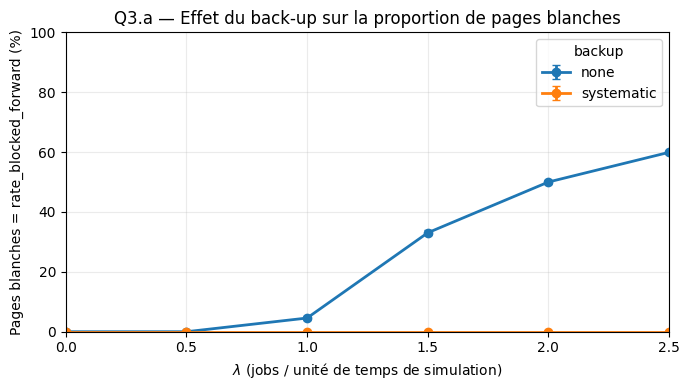

In [31]:
# Analyse + plot (moyenne et écart-type de rate_blocked_forward)

import os
import numpy as np
import matplotlib.pyplot as plt

df_none = pd.read_csv(none_csv)
df_sys = pd.read_csv(sys_csv)
df = pd.concat([df_none, df_sys], ignore_index=True)

metric = "rate_blocked_forward"  # page blanche
g = df.groupby(["lam", "backup"])[metric]
stats = g.agg(["mean", "std", "count"]).reset_index().sort_values(["backup", "lam"])

# Mise en % (rate_* est une proportion dans [0,1])
stats["mean_pct"] = 100.0 * stats["mean"]
stats["std_pct"] = 100.0 * stats["std"].fillna(0.0)

plt.figure(figsize=(7, 4))
for backup, sub in stats.groupby("backup"):
    plt.errorbar(sub["lam"], sub["mean_pct"], yerr=sub["std_pct"], marker="o", capsize=3, linewidth=2, label=backup)

plt.title("Q3.a — Effet du back-up sur la proportion de pages blanches")
plt.xlabel(r"$\lambda$ (jobs / unité de temps de simulation)")
plt.ylabel("Pages blanches = rate_blocked_forward (%)")
plt.grid(True, alpha=0.25)
plt.legend(title="backup")

# Faire démarrer l'axe des x à 0 (avec un point à λ=0)
xvals = sorted(stats["lam"].unique().tolist())
plt.xlim(0, float(max(xvals)))
plt.xticks(xvals)
plt.ylim(0, 100)
plt.tight_layout()

plot_path = os.path.join(OUT_DIR, f"{OUT_PREFIX}_rate_blocked_forward.png")
plt.savefig(plot_path, dpi=200)
print("Wrote:", plot_path)

# Tableau récapitulatif (optionnel)
tab = stats.pivot(index="lam", columns="backup", values="mean_pct").reset_index()
tab = tab.rename(columns={"none": "none_mean_pct", "systematic": "systematic_mean_pct"})
if "none_mean_pct" in tab.columns and "systematic_mean_pct" in tab.columns:
    tab["gain_pct_points"] = tab["none_mean_pct"] - tab["systematic_mean_pct"]
tab = tab.round(3)
tab


**Que montrent les résultats ?**  
Sans back-up, la proportion de pages blanches augmente vite avec la charge : environ 4% à $\lambda=1.0$, environ 33% à $\lambda=1.5$, 50% à $\lambda=2.0$ et environ 60% à $\lambda=2.5$.  
Avec un back-up systématique, elle reste nulle sur toute la plage testée : les résultats bloqués ne sont plus perdus, ils sont sauvegardés puis réinjectés plus tard.


**Conclusion.**  
Le back-up transforme donc une perte visible (page blanche) en résultat différé. L’impact sur les délais et l’accumulation (backlog) est discuté dans les sous-questions suivantes.


### <span style="color:#4a90e2"> 3.b Quels problèmes peuvent surgir avec cette solution ?

### <span style="color:#4a90e2"> 3.c Discutez des avantages d’un back-up aléatoire plutôt que systématique.

Un back-up **systématique** (probabilité $p=1$) minimise la perte : dès qu’un résultat ne peut pas entrer dans la file de renvoi, il est sauvegardé puis réessayé. En contrepartie, il peut créer une **accumulation massive** si l’étape 2 est le goulet.

Un back-up **aléatoire** (probabilité $p\in(0,1)$) met en œuvre un compromis : lorsqu’un résultat est bloqué, on le sauvegarde avec probabilité $p$ et on l’abandonne sinon. Cela permet de maîtriser la charge (taille du back-up) au prix d’un taux de pages blanches non nul. Intuitivement : plus $p$ est grand, plus on réduit les pertes, mais plus on risque d’augmenter le backlog et les délais.

Les tests Q3.c illustrent ce compromis ($\lambda=4$, $\mu_2=1$, $k_f=3$) :
- `systematic (p=1)` : `rate_dropped = 0`, mais `mean_time_in_system \approx 1591` et `rest_in_backup \approx 9687` (backlog très important).
- `probabilistic (p=0.5)` : `rate_dropped \approx 0.3567` (pertes réduites), mais backlog encore élevé (`rest_in_backup \approx 2634`) et délai très grand (`\approx 909`).
- `probabilistic (p=0.25)` : quasi pas d’effet sur la perte (`rate_dropped \approx 0.496` proche de `none`), et pas de backlog (le système abandonne trop souvent au lieu d’absorber la charge).

Ainsi, le back-up aléatoire peut être avantageux si l’on vise un niveau de fiabilité ciblé tout en limitant l’occupation du stock de sauvegarde. Dans une pratique d’ingénierie, $p$ gagnerait à être adaptatif (fonction de la charge observée) plutôt que fixé.

### Appui expérimental attendu

- Variation de la probabilité de back-up

- Courbes compromis fiabilité / surcharge

In [32]:
# Tests Q3.c — back-up aléatoire vs systématique (compromis fiabilité / surcharge)
# Ici on force un cas où la file 2 (envoi) sature souvent (kf petit, μ_send faible).

OUT_DIR = "results_q3c"

lam = 4.0
mu_exec = 1.0
mu_send = 1.0
K = 3
ks = 15
kf = 3

experiments = []

# Référence : pas de back-up (pages blanches possibles)
summary_csv, _ = run_waterfall(
    out_prefix="q3c_none",
    out_dir=OUT_DIR,
    lam=lam,
    mu_exec=mu_exec,
    mu_send=mu_send,
    K=K,
    ks=ks,
    kf=kf,
    backup="none",
)
s = summarize_experiment(summary_csv)
s.update({"backup": "none", "p": 0.0})
experiments.append(s)

# Back-up systématique (fiabilité maximale, surcharge/backlog possible)
summary_csv, _ = run_waterfall(
    out_prefix="q3c_systematic",
    out_dir=OUT_DIR,
    lam=lam,
    mu_exec=mu_exec,
    mu_send=mu_send,
    K=K,
    ks=ks,
    kf=kf,
    backup="systematic",
)
s = summarize_experiment(summary_csv)
s.update({"backup": "systematic", "p": 1.0})
experiments.append(s)

# Back-up probabiliste (compromis)
for p in [0.25, 0.5, 0.75]:
    summary_csv, _ = run_waterfall(
        out_prefix=f"q3c_prob_p{p}",
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup="probabilistic",
        backup_p=p,
    )
    s = summarize_experiment(summary_csv)
    s.update({"backup": "probabilistic", "p": p})
    experiments.append(s)

print_table(
    experiments,
    cols=["backup", "p", "rate_dropped", "mean_time_in_system", "rest_in_backup", "not_completed_yet"],
)


backup        | p    | rate_dropped | mean_time_in_system | rest_in_backup | not_completed_yet
--------------+------+--------------+---------------------+----------------+------------------
none          | 0    | 0.4988       | 7.952               | 0              | 0                
systematic    | 1    | 0            | 1591                | 9687           | 9691             
probabilistic | 0.25 | 0.4958       | 12.54               | 0              | 0                
probabilistic | 0.5  | 0.3567       | 909.1               | 2634           | 2638             
probabilistic | 0.75 | 0.1781       | 1365                | 6178           | 6182             


### <span style="color:#4a90e2"> 3.d Calculez le temps de séjour moyen et la variance empirique dans ce modèle.

On note $T$ le **temps de séjour** (temps passé dans le système) d’un job, défini par :

$$
T_i = d_i - a_i,
$$
où $a_i$ est le temps d’arrivée et $d_i$ le temps de départ (envoi effectif vers le front) pour le job $i$.

Sur un échantillon de $N$ jobs complétés, on estime empiriquement :

$$
\widehat{\mathbb{E}}[T] = \frac{1}{N}\sum_{i=1}^{N} T_i,
\qquad
\widehat{\mathrm{Var}}(T) = \frac{1}{N}\sum_{i=1}^{N} \left(T_i - \widehat{\mathbb{E}}[T]\right)^2.
$$

Dans notre simulation (cellule de test ci-dessous, $\lambda=2$, $\mu_1=1$, $\mu_2=2.5$, $K=3$, $k_s=15$, $k_f=3$, back-up systématique), on obtient sur $N=199\,465$ jobs complétés :
- $\widehat{\mathbb{E}}[T] \approx 3.435$,
- $\widehat{\mathrm{Var}}(T) \approx 6.129$.

La variance quantifie l’hétérogénéité des délais : une valeur élevée indique une expérience utilisateur plus imprévisible (certains jobs très rapides, d’autres beaucoup plus lents).

### Appui expérimental attendu

- Tableaux comparatifs moyenne / variance

- Mise en relation avec les paramètres du système

In [33]:
# Tests Q3.d — calcul empirique du temps de séjour moyen et de la variance
# On utilise le fichier *_jobs.csv (jobs complétés), puis T = depart - arrival.

OUT_DIR = "results_q3d"

# Exemple de scénario (à ajuster) :
lam = 2.0
mu_exec = 1.0
mu_send = 2.5
K = 3
ks = 15
kf = 3
backup = "systematic"

summary_csv, jobs_csv = run_waterfall(
    out_prefix="q3d_example",
    out_dir=OUT_DIR,
    lam=lam,
    mu_exec=mu_exec,
    mu_send=mu_send,
    K=K,
    ks=ks,
    kf=kf,
    backup=backup,
)

jobs = read_csv_dicts(jobs_csv)
times = [float(j["depart"]) - float(j["arrival"]) for j in jobs]

emp_mean = statistics.mean(times) if times else 0.0
emp_var = statistics.pvariance(times) if len(times) > 1 else 0.0

# Comparaison : moyenne des métriques "par run" dans le summary (peut différer légèrement).
s = summarize_experiment(summary_csv)

{
    "E[T] empirical (jobs.csv)": emp_mean,
    "Var(T) empirical (jobs.csv)": emp_var,
    "mean_time_in_system (summary avg)": s.get("mean_time_in_system", 0.0),
    "var_time_in_system (summary avg)": s.get("var_time_in_system", 0.0),
    "n_jobs_completed": len(times),
}


{'E[T] empirical (jobs.csv)': 3.434564916440363,
 'Var(T) empirical (jobs.csv)': 6.129027292581146,
 'mean_time_in_system (summary avg)': 3.433438929145587,
 'var_time_in_system (summary avg)': 6.082590914681587,
 'n_jobs_completed': 199465}